# Post-TARE Adoption KPIs: Bill Savings & Demand Change
**Author:** Jordan M. Joseph, PhD — Carnegie Mellon University

Computes bill savings ratio and electricity demand change metrics from TARE model outputs and EUSS data.

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from config import PROJECT_ROOT
from cmu_tare_model.constants import VALID_MENU_MPS
from cmu_tare_model.utils.load_exported_results_to_df import load_measure_package_data

from cmu_tare_model.adoption_kpis import (
    load_euss_baseline, load_euss_upgrade, mp_to_upgrade,
    calculate_spark_gap,
    compute_scenario_demand, aggregate_demand_by_state,
    compute_bill_savings_ratio, aggregate_bill_savings_by_state,
)
from cmu_tare_model.adoption_kpis.visualize_geospatial_data import (
    prepare_state_geodataframe, create_choropleth_map,
)
from cmu_tare_model.adoption_kpis.data_loading import (
    FUEL_PRICES_PATH, SHAPEFILE_PATH,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
print("[OK] Imports loaded")

Project root directory: c:\users\jorda\desktop\projects\cmu-tare-model
[OK] Imports loaded


In [2]:
SELECTABLE_MPS = [mp for mp in VALID_MENU_MPS if mp != 0]

try:
    _ = input_measure_package
    batch_mode = True
    selected_mps = [int(input_measure_package)]
    print(f"BATCH MODE: Running for MP{selected_mps[0]}")
except NameError:
    batch_mode = False
    print(f"Available measure packages: {SELECTABLE_MPS}")
    mp_input = input("Enter MP numbers (comma-separated, or 'all'): ").strip()
    if mp_input.lower() == 'all':
        selected_mps = SELECTABLE_MPS
    else:
        selected_mps = [int(x.strip()) for x in mp_input.split(',') if x.strip().isdigit()]
        selected_mps = [mp for mp in selected_mps if mp in SELECTABLE_MPS]
    if not selected_mps:
        selected_mps = [4]
        print("No valid MPs selected. Defaulting to MP4.")

print(f"Selected measure packages: {selected_mps}")

Available measure packages: [3, 4]
Selected measure packages: [3, 4]


In [3]:
# Load TARE model outputs for selected measure packages.
# These contain per-building lifetime fuel costs used for bill savings ratio.

try:
    _ = DATAFRAMES_BY_MP
    print(f"DATAFRAMES_BY_MP already loaded: {list(DATAFRAMES_BY_MP.keys())}")
except NameError:
    try:
        _ = output_folder_path
        print(f"Using existing output_folder_path: {output_folder_path}")
    except NameError:
        output_folder_path = os.path.join(PROJECT_ROOT, "cmu_tare_model", "output_results")
        location_id = input("Enter location ID (e.g., 'National' or 'PA'): ").strip()
        model_run_date_time = input("Enter model run timestamp (YYYY-MM-DD_HH-MM): ").strip()

    DATAFRAMES_BY_MP = {}
    for mp in selected_mps:
        DATAFRAMES_BY_MP[mp] = load_measure_package_data(
            mp, output_folder_path, location_id, model_run_date_time
        )
    print(f"[OK] Loaded TARE data for MPs: {list(DATAFRAMES_BY_MP.keys())}")

Loading MP3 data...
  fixed_base: ✓ 
MP3 loading complete!

Loading MP4 data...
  fixed_base: ✓ 
MP4 loading complete!

[OK] Loaded TARE data for MPs: [3, 4]


In [4]:
df_baseline = load_euss_baseline()
print(f"Baseline: {len(df_baseline):,} occupied SF homes")

upgrade_data = {}
for mp in selected_mps:
    upgrade_name = mp_to_upgrade(mp)
    print(f"\nLoading MP{mp} ({upgrade_name})...")
    upgrade_data[mp] = load_euss_upgrade(upgrade_name)
    print(f"  MP{mp}: {len(upgrade_data[mp]):,} applicable homes")

print(f"\n[OK] EUSS data loaded")

Loading baseline from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\baseline_metadata_and_annual_results.csv


c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\adoption_kpis\data_loading.py:176: DtypeWarning: Columns (61,113,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, index_col="bldg_id")


  After occupancy filter: 482,597 / 548,916
  After housing type filter (['Single-Family Attached', 'Single-Family Detached']): 331,531
Baseline: 331,531 occupied SF homes

Loading MP3 (upgrade03)...
Loading upgrade03 from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\upgrade03_metadata_and_annual_results.csv


c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\adoption_kpis\data_loading.py:210: DtypeWarning: Columns (61,113,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, index_col="bldg_id")


  After occupancy filter: 482,597 / 548,916
  After housing type filter: 331,531
  After applicability filter: 331,526
  MP3: 331,526 applicable homes

Loading MP4 (upgrade04)...
Loading upgrade04 from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\upgrade04_metadata_and_annual_results.csv


c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\adoption_kpis\data_loading.py:210: DtypeWarning: Columns (61,113,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, index_col="bldg_id")


  After occupancy filter: 482,597 / 548,916
  After housing type filter: 331,531
  After applicability filter: 331,526
  MP4: 331,526 applicable homes

[OK] EUSS data loaded


In [5]:
bill_savings_results = {}
for mp in selected_mps:
    print(f"\n{'='*60}")
    print(f"BILL SAVINGS RATIO — MP{mp}, Natural Gas homes")
    print(f"{'='*60}")
    df_tare = DATAFRAMES_BY_MP[mp]['fixed_base']['inmap']
    df_ratio = compute_bill_savings_ratio(
        df_tare, mp=mp, policy_scenario='iraRef',
        fuel_filter='Natural Gas', verbose=True,
        df_euss=df_baseline,
    )
    df_ratio_state = aggregate_bill_savings_by_state(df_ratio, verbose=True)
    bill_savings_results[mp] = df_ratio_state

print("\n[OK] Bill savings ratio complete")


BILL SAVINGS RATIO — MP3, Natural Gas homes
Filtered to 'Natural Gas': 180,939 / 331,531 homes
Per-building records (non-null ratio): 155,344
Median bill savings ratio: 0.867
Mean bill savings ratio:   1.253
States where median home saves money (ratio < 1): 39 / 49
National median of state medians: 0.771

BILL SAVINGS RATIO — MP4, Natural Gas homes
Filtered to 'Natural Gas': 180,939 / 331,531 homes
Per-building records (non-null ratio): 155,344
Median bill savings ratio: 0.585
Mean bill savings ratio:   0.622
States where median home saves money (ratio < 1): 49 / 49
National median of state medians: 0.520

[OK] Bill savings ratio complete


In [6]:
for mp, df_state in bill_savings_results.items():
    print(f"\n===== BILL SAVINGS RATIO (MP{mp}, NG homes) =====")
    n_savings = (df_state['median_bill_savings_ratio'] < 1.0).sum()
    print(f"States where median home saves money: {n_savings} / {len(df_state)}")
    print(f"National median: {df_state['median_bill_savings_ratio'].median():.3f}")
    print(f"\nTop 5 (best for electrification):")
    print(df_state.nsmallest(5, 'median_bill_savings_ratio')[
        ['state', 'median_bill_savings_ratio', 'weighted_ratio', 'home_count']
    ].to_string(index=False))
    print(f"\nBottom 5 (worst for electrification):")
    print(df_state.nlargest(5, 'median_bill_savings_ratio')[
        ['state', 'median_bill_savings_ratio', 'weighted_ratio', 'home_count']
    ].to_string(index=False))


===== BILL SAVINGS RATIO (MP3, NG homes) =====
States where median home saves money: 39 / 49
National median: 0.771

Top 5 (best for electrification):
state  median_bill_savings_ratio  weighted_ratio  home_count
   FL                      0.400           0.393        1098
   NC                      0.527           0.515        3479
   ND                      0.588           0.618         402
   GA                      0.601           0.591        5111
   DC                      0.605           0.598         338

Bottom 5 (worst for electrification):
state  median_bill_savings_ratio  weighted_ratio  home_count
   NJ                      1.298           1.292        6742
   NY                      1.206           1.141        8652
   MI                      1.162           1.125        9884
   CA                      1.124           1.081       25133
   CT                      1.118           1.089        1141

===== BILL SAVINGS RATIO (MP4, NG homes) =====
States where median home save

In [7]:
demand_results = {}
for mp in selected_mps:
    print(f"\n{'='*60}")
    print(f"DEMAND CHANGE — MP{mp}, all fuels, 100% adoption")
    print(f"{'='*60}")
    df_demand = compute_scenario_demand(
        df_baseline, upgrade_data[mp], fuel_filter=None, verbose=True,
    )
    df_demand_state = aggregate_demand_by_state(df_demand, verbose=True)
    demand_results[mp] = df_demand_state

print("\n[OK] Demand change complete")


DEMAND CHANGE — MP3, all fuels, 100% adoption

--- Demand Scenario Summary (100% adoption, all fuels) ---
Total homes: 331,526
Weighted electricity demand change:  +451,076.2 GWh (grid impact)
Weighted total site energy change:   -799,889.7 GWh (efficiency)
✓ Demand accounting check passed

--- State-Level Demand Summary ---
States: 49
Total elec demand change:    +451076.2 GWh (grid impact)
Total site energy change:    -799889.7 GWh (efficiency)

DEMAND CHANGE — MP4, all fuels, 100% adoption

--- Demand Scenario Summary (100% adoption, all fuels) ---
Total homes: 331,526
Weighted electricity demand change:  +186,790.5 GWh (grid impact)
Weighted total site energy change:   -1,064,175.4 GWh (efficiency)
✓ Demand accounting check passed

--- State-Level Demand Summary ---
States: 49
Total elec demand change:    +186790.5 GWh (grid impact)
Total site energy change:    -1064175.4 GWh (efficiency)

[OK] Demand change complete


In [8]:
for mp, df_state in demand_results.items():
    print(f"\n===== DEMAND CHANGE (MP{mp}, GWh, all fuels, 100% adoption) =====")
    print(f"Total elec demand change: {df_state['elec_change_gwh'].sum():+.1f} GWh")
    print(f"Total site energy change: {df_state['site_energy_change_gwh'].sum():+.1f} GWh")
    print(f"\nTop 5 (largest elec demand increase):")
    print(df_state[['state', 'elec_change_gwh', 'pct_elec_demand_change',
                     'site_energy_change_gwh', 'pct_site_energy_change']].head(5).to_string(index=False))
    print(f"\nBottom 5:")
    print(df_state[['state', 'elec_change_gwh', 'pct_elec_demand_change',
                     'site_energy_change_gwh', 'pct_site_energy_change']].tail(5).to_string(index=False))


===== DEMAND CHANGE (MP3, GWh, all fuels, 100% adoption) =====
Total elec demand change: +451076.2 GWh
Total site energy change: -799889.7 GWh

Top 5 (largest elec demand increase):
state  elec_change_gwh  pct_elec_demand_change  site_energy_change_gwh  pct_site_energy_change
   NY         49940.21                 1285.37               -65624.93                  -54.94
   MI         46718.92                 1213.23               -47620.46                  -48.50
   IL         39893.46                  725.60               -56529.57                  -55.46
   OH         34707.89                  365.27               -53566.64                  -54.78
   PA         34507.23                  345.39               -52465.13                  -54.11

Bottom 5:
state  elec_change_gwh  pct_elec_demand_change  site_energy_change_gwh  pct_site_energy_change
   AL          -545.46                   -9.68                -7693.16                  -60.19
   LA          -706.34                  -19.33

[OK] Shapefile loaded: 52 features
  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_bill_savings_ratio_map_MP3.png


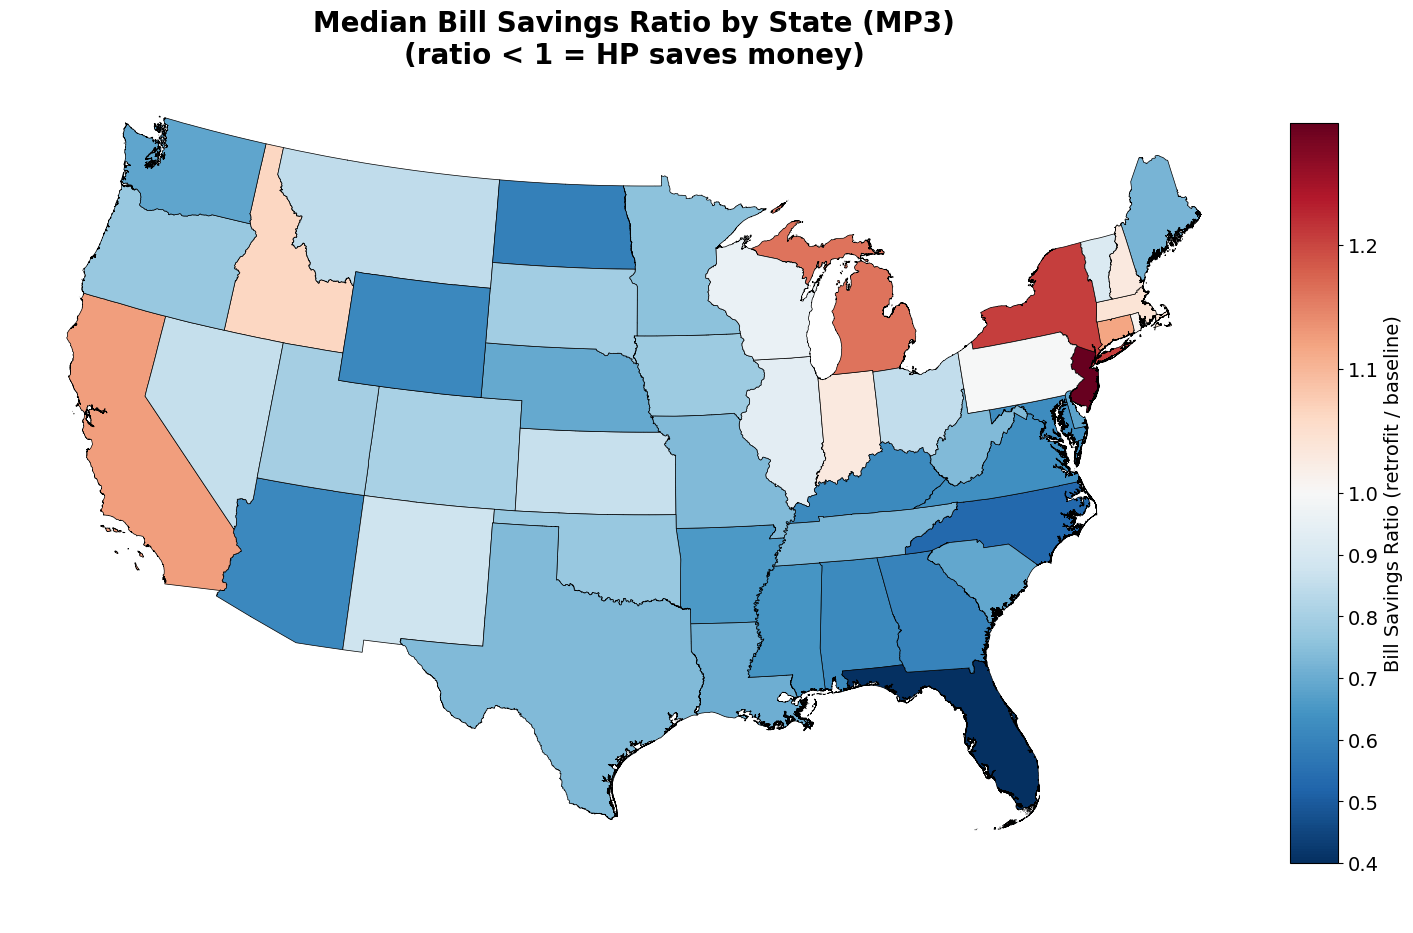

  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_elec_demand_change_map_MP3.png


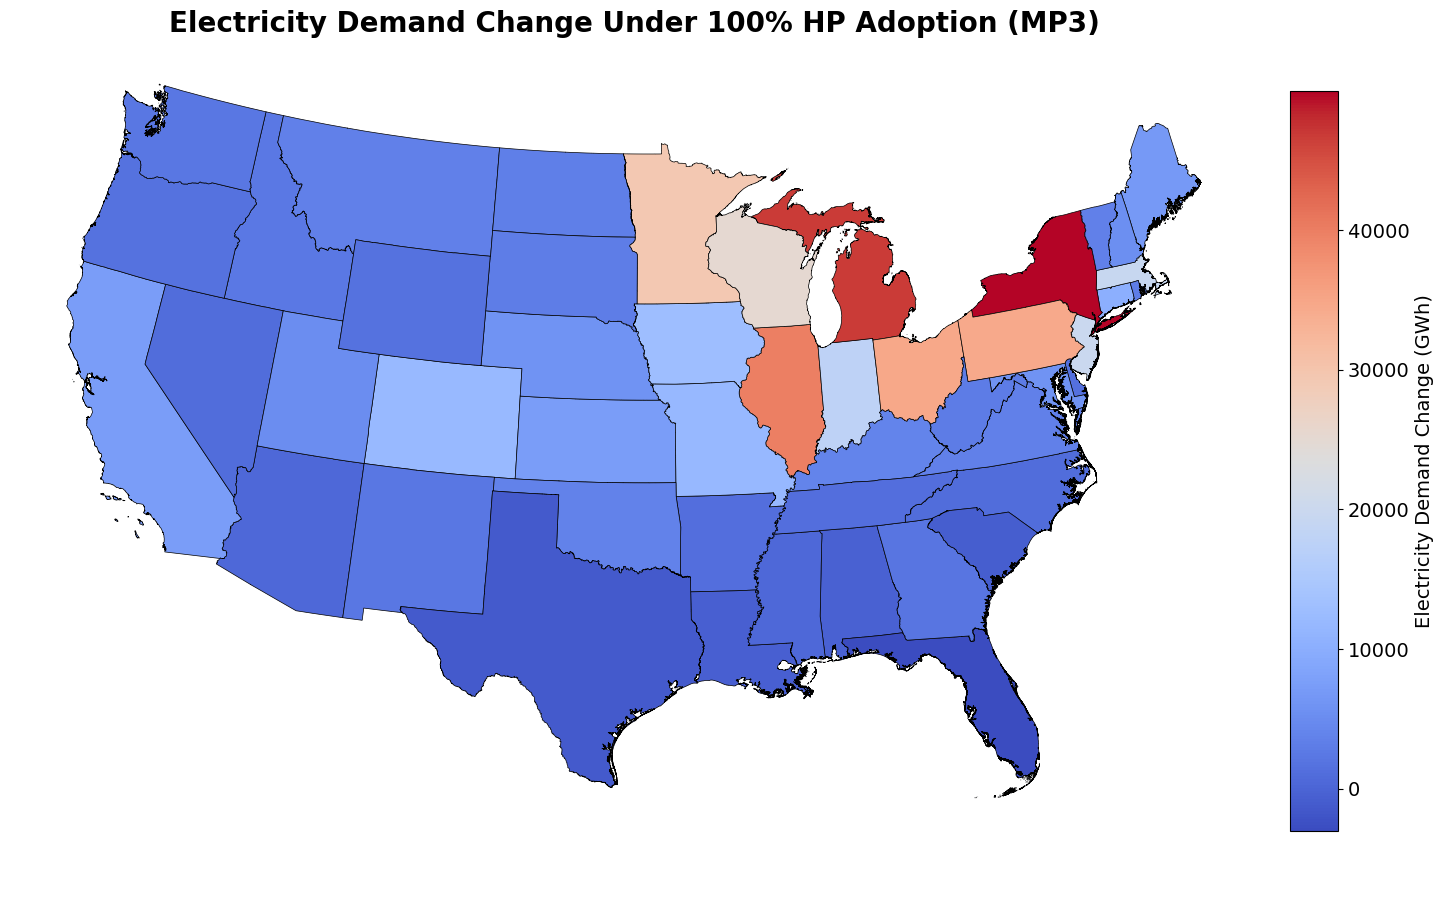

  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_bill_savings_ratio_map_MP4.png


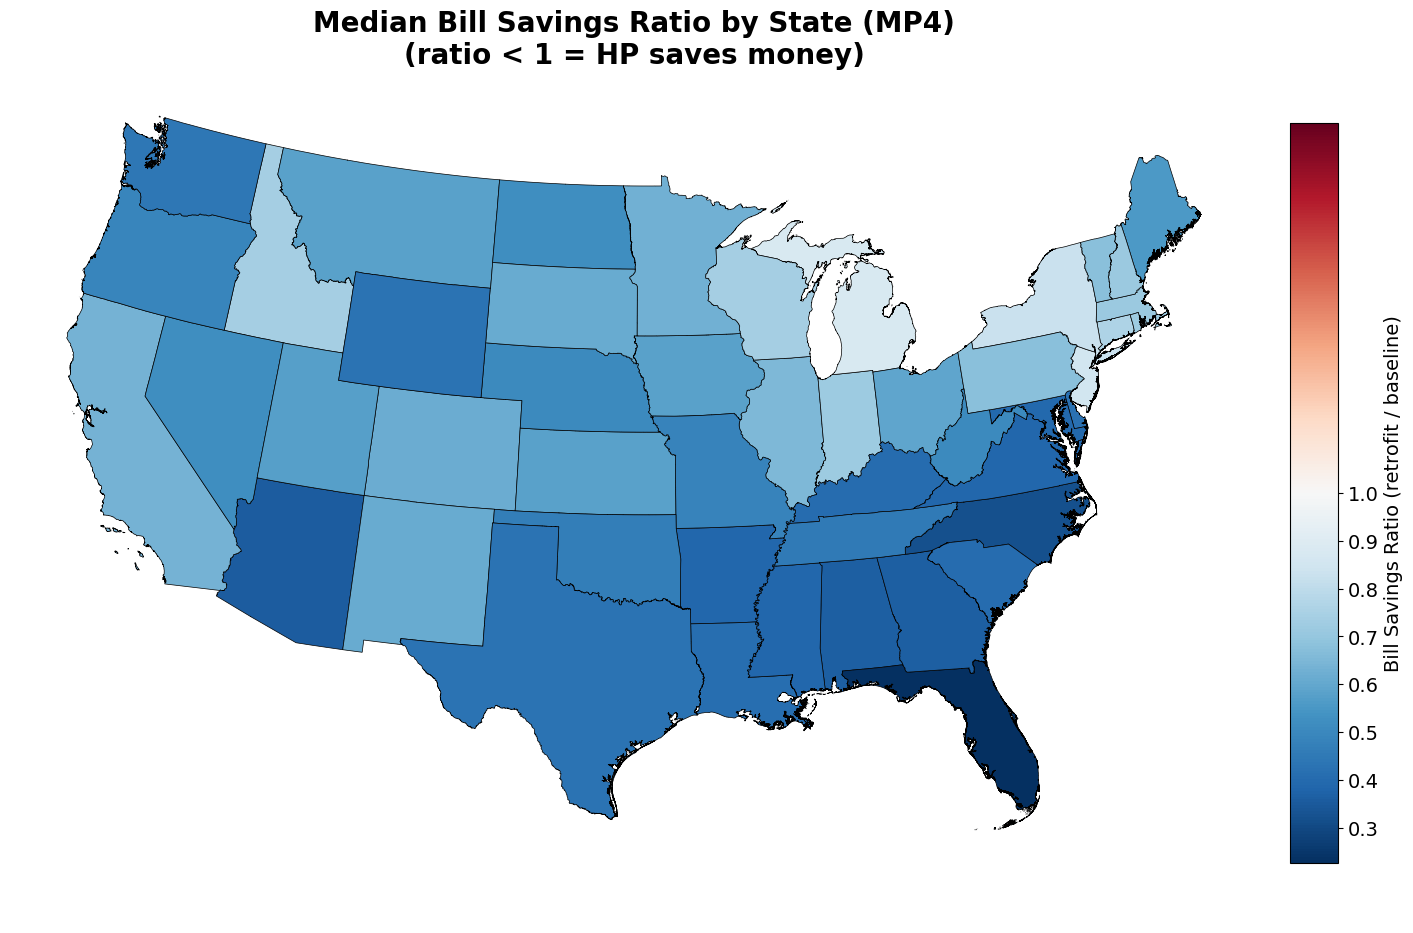

  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_elec_demand_change_map_MP4.png


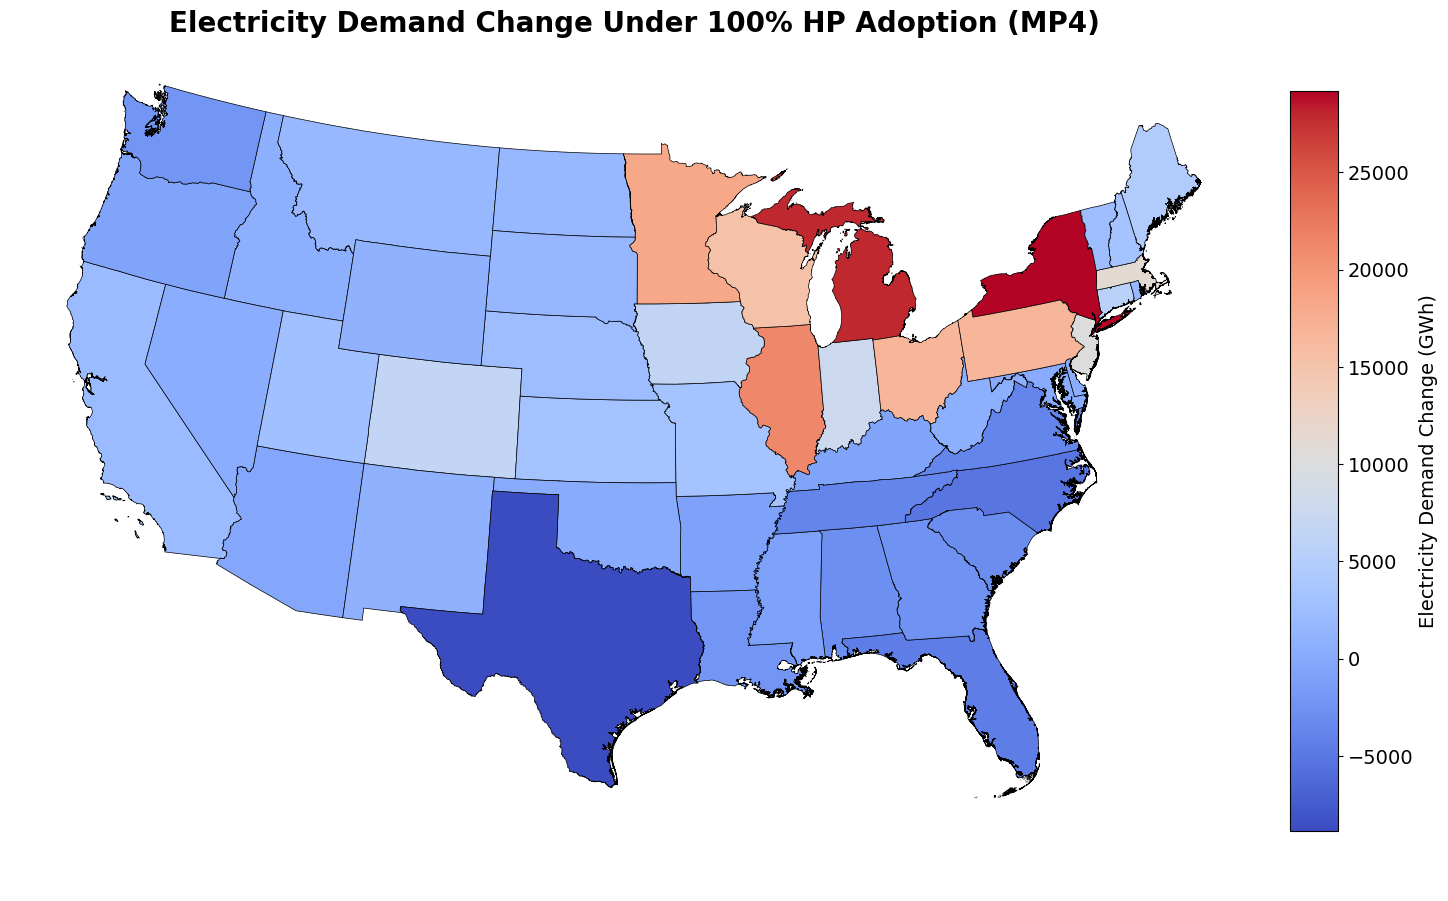

[OK] Maps generated


In [10]:
gdf_states_raw = None
try:
    gdf_states_raw = gpd.read_file(SHAPEFILE_PATH)
    print(f"[OK] Shapefile loaded: {len(gdf_states_raw)} features")
except Exception as e:
    print(f"[WARN] Shapefile not loaded: {e} — skipping maps")

if gdf_states_raw is not None:
    for mp in selected_mps:
        # Bill savings ratio map (diverging, centered at 1.0)
        df_ratio_state = bill_savings_results[mp]
        _, gdf_ratio_conus, gdf_ratio_alaska = prepare_state_geodataframe(
            gdf_states_raw, df_ratio_state, merge_col='state'
        )
        ratio_vals = pd.concat([
            gdf_ratio_conus['median_bill_savings_ratio'],
            gdf_ratio_alaska['median_bill_savings_ratio'],
        ]).dropna()
        # TwoSlopeNorm requires vmin < vcenter < vmax — clamp if all states
        # fall on one side of 1.0 (e.g. all ratios > 1 → force vmin below 1.0)
        r_min = min(ratio_vals.min(), 0.999)
        r_max = max(ratio_vals.max(), 1.001)
        create_choropleth_map(
            gdf_ratio_conus, gdf_ratio_alaska,
            column='median_bill_savings_ratio',
            title=f'Median Bill Savings Ratio by State (MP{mp})\n(ratio < 1 = HP saves money)',
            cbar_label='Bill Savings Ratio (retrofit / baseline)',
            output_path=os.path.join(PROJECT_ROOT, f"state_bill_savings_ratio_map_MP{mp}.png"),
            cmap='RdBu_r',
            norm=mcolors.TwoSlopeNorm(vmin=r_min, vcenter=1.0, vmax=r_max),
            show_plot=True,
        )
        # Demand change map (diverging)
        df_demand_state = demand_results[mp]
        _, gdf_demand_conus, gdf_demand_alaska = prepare_state_geodataframe(
            gdf_states_raw, df_demand_state, merge_col='state'
        )
        create_choropleth_map(
            gdf_demand_conus, gdf_demand_alaska,
            column='elec_change_gwh',
            title=f'Electricity Demand Change Under 100% HP Adoption (MP{mp})',
            cbar_label='Electricity Demand Change (GWh)',
            output_path=os.path.join(PROJECT_ROOT, f"state_elec_demand_change_map_MP{mp}.png"),
            cmap='coolwarm', show_plot=True,
        )
    print("[OK] Maps generated")
else:
    print("[WARN] Maps skipped")

In [ ]:
print("=" * 70)
print("SUMMARY")
print("=" * 70)

for mp in selected_mps:
    df_bs = bill_savings_results[mp]
    df_dem = demand_results[mp]
    n_savings = (df_bs['median_bill_savings_ratio'] < 1.0).sum()
    total_states = len(df_bs)
    nat_median = df_bs['median_bill_savings_ratio'].median()
    ratio_min = df_bs['median_bill_savings_ratio'].min()
    ratio_max = df_bs['median_bill_savings_ratio'].max()
    total_elec_gwh = df_dem['elec_change_gwh'].sum()
    total_site_gwh = df_dem['site_energy_change_gwh'].sum()
    print(f"\n--- MP{mp} ---")
    print(f"Bill savings (NG homes): {n_savings}/{total_states} states save money "
          f"| national median ratio: {nat_median:.3f} | range: {ratio_min:.3f}–{ratio_max:.3f}")
    print(f"Demand change (all fuels): elec {total_elec_gwh:+.1f} GWh "
          f"| site {total_site_gwh:+.1f} GWh")

print("\n[DONE]")